# EDA 

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from glob import glob

# Locate data directory (handle possible trailing space in folder name)
candidates = ['/home/tuong/Job/data', '/home/tuong/Job/data ']
data_dir = next((d for d in candidates if os.path.isdir(d)), candidates[0])
print('Using data directory:', data_dir)

# Find matching files (handle slight name differences)
files = []
files += sorted(glob(os.path.join(data_dir, 'danh_sach_tim_14_05.*')))
files += sorted(glob(os.path.join(data_dir, 'danh_sach_tim_16-05.*')))

dfs = []
for path in files:
    try:
        if path.lower().endswith(('.xls', '.xlsx', '.xlsm', '.xlsb')):
            dfs.append(pd.read_excel(path, engine='openpyxl'))
        else:
            try:
                dfs.append(pd.read_csv(path, encoding='utf-8'))
            except UnicodeDecodeError:
                dfs.append(pd.read_csv(path, encoding='latin1'))
    except Exception as e:
        print(f'Failed reading {path}: {e}')

if dfs:
    dataset = pd.concat(dfs, ignore_index=True)
    print(dataset.head())
else:
    print('No files loaded. Searched files:', files)

Using data directory: /home/tuong/Job/data 
              Ngày tìm           Tên KH        SĐT      Nhà mạng  SĐT 2  \
0  14-05-2026 16:42:17         Nhật Huy  896140216      MobiFone    NaN   
1  14-05-2026 16:42:00  Bùi Thanh Huỳnh  985203556       Viettel    NaN   
2  14-05-2026 16:41:54        Thanh Lâm  528802924  Vietnamobile    NaN   
3  14-05-2026 16:41:14          Nhóc Lì  367721401       Viettel    NaN   
4  14-05-2026 16:38:29      Đầu Lông Cu  369512257       Viettel    NaN   

  Nhà mạng 2  Số lần tìm Email  Emails Giới tính Ngày sinh Location  Comment  \
0        NaN           1   NaN     NaN       NaN       NaN      NaN      NaN   
1        NaN           1   NaN     NaN       Nam       NaN   Hà Nội      NaN   
2        NaN           1   NaN     NaN       NaN       NaN      NaN      NaN   
3        NaN           1   NaN     NaN       NaN       NaN      NaN      NaN   
4        NaN           1   NaN     NaN       Nam       NaN      NaN      NaN   

                        

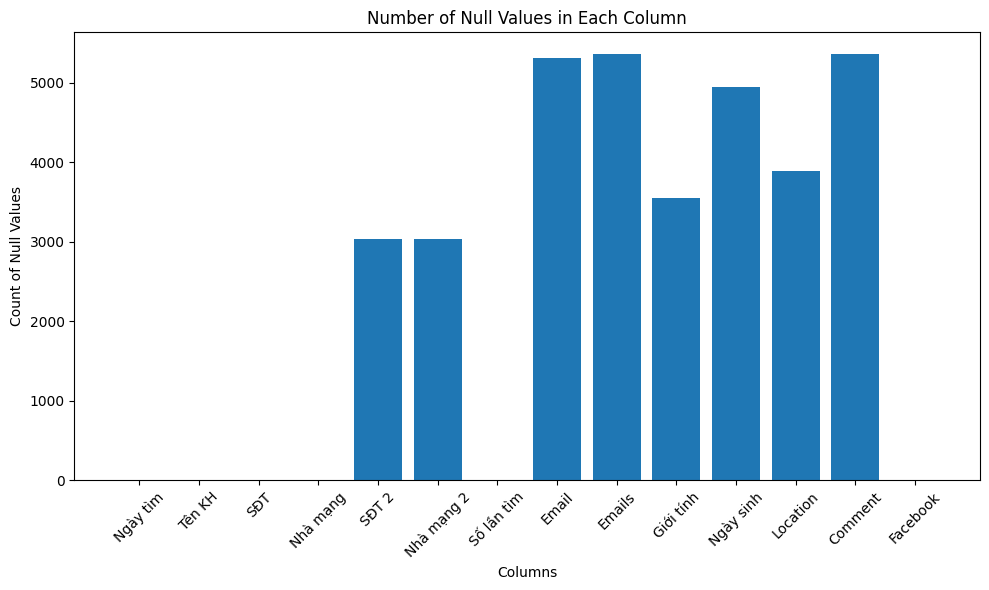

In [21]:
#visualize data null values
plt.figure(figsize=(10, 6))
plt.bar(dataset.columns, dataset.isnull().sum())
plt.xticks(rotation=45)
plt.title('Number of Null Values in Each Column')
plt.xlabel('Columns')
plt.ylabel('Count of Null Values')
plt.tight_layout()
plt.show()

In [22]:
# Xuất file
output_path = os.path.join(data_dir, 'combined_dataset.csv')
try:
    dataset.to_csv(output_path, index=False)
    print(f'Combined dataset saved to {output_path}')
except Exception as e:
    print(f'Failed to save combined dataset: {e}')

Combined dataset saved to /home/tuong/Job/data /combined_dataset.csv


# layer 1: check cơ bản các col quan trọng như sđt(1,2), fb


In [23]:
class checking:
    def __init__(self, dataset):
        self.dataset = dataset

    def check_null_values(self):
        """check dữ liệu null 3 cột SĐT, Facebook, SĐT 2"""
        null_counts = self.dataset[['SĐT', 'Facebook', 'SĐT 2']].isnull().sum()
        print("Null values in each column:")
        print(null_counts)

    def visualize_null_values(self):
        plt.figure(figsize=(10, 6))
        plt.bar(self.dataset[['SĐT', 'Facebook', 'SĐT 2']].columns, self.dataset[['SĐT', 'Facebook', 'SĐT 2']].isnull().sum())
        plt.xticks(rotation=45)
        plt.title('Number of Null Values in Each Column')
        plt.xlabel('Columns')
        plt.ylabel('Count of Null Values')
        plt.tight_layout()
        plt.show()

class preprocessing:
    def __init__(self, dataset):
        self.dataset = dataset

    def evaluate_null_values(self):
        """nếu dữ liệu null ở cả 3 cột SĐT, Facebook, SĐT 2 thì sẽ xóa dòng đó"""
        null_counts = self.dataset[['SĐT', 'Facebook', 'SĐT 2']].isnull().sum(axis=1)
        self.dataset = self.dataset[null_counts < 3]

    def fill_null_values(self):
        """tìm giá trị điền vào cho các cột SĐT, Facebook, SĐT 2 nếu có dữ liệu null"""
        pass 

Null values in each column:
SĐT            0
Facebook       0
SĐT 2       3035
dtype: int64


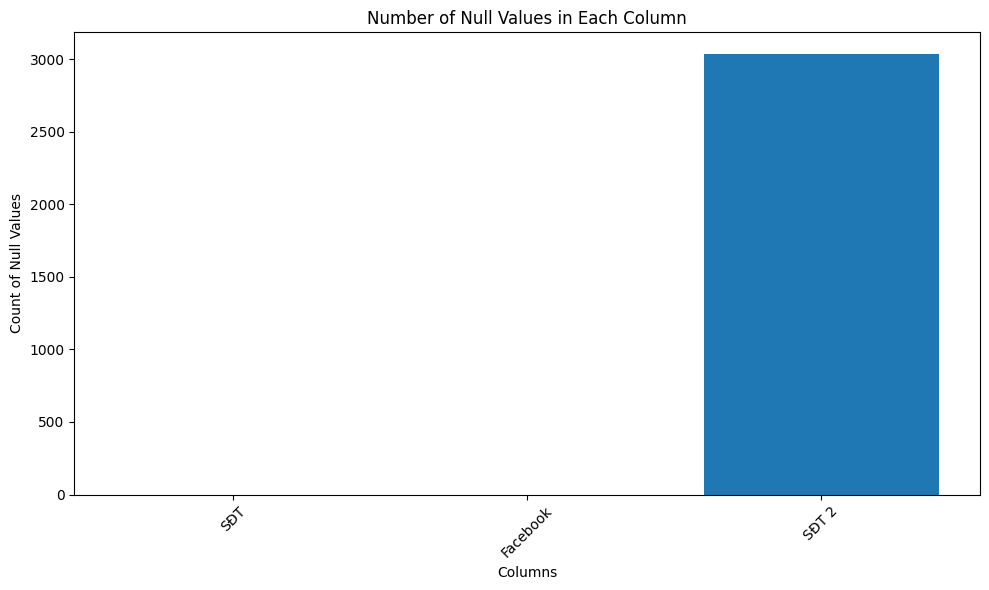

In [24]:
# truyền tham số dataset vào class checking để kiểm tra dữ liệu null
checker = checking(dataset)
checker.check_null_values()
checker.visualize_null_values()

#
checkerv2 = preprocessing(dataset)
checkerv2.evaluate_null_values()
checkerv2.fill_null_values()

In [25]:
#check duplitecate values
duplicate_counts = dataset.duplicated().sum()
print(f'Number of duplicate rows: {duplicate_counts}')

Number of duplicate rows: 0


# 

# layer 2: check khả năng sống của data(sdt, sdt 2, zalo, fb)


In [26]:
class LinkAvailabilityChecker:
    def __init__(self, dataset):
        self.dataset = dataset

    def check_link_availability(self):
        """kiểm tra tính khả dụng của các liên kết trong cột Facebook"""
        pass  # Implement link checking logic here